# E-Commerce Logistics: EDA Mini‑Project
This project performs EDA on an e-commerce retail dataset to identify sales trends, customer purchasing behavior, product performance, and revenue patterns using Python.

**Source link:** https://amanxai.com/2025/03/02/try-these-datasets-to-master-data-cleaning/  

## 1. importing libraries and loading the dataset

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("data.csv", encoding='latin1')

In [4]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 2. initial data exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


## 3. data cleaning and preprocessing

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 5268


In [9]:
df = df.drop_duplicates()

print(f"Updated shape: {df.shape}")

Updated shape: (536641, 8)


In [10]:
negative_quantity = df[df['Quantity'] < 0]

print(f"Transactions with negative quantity: {negative_quantity.shape[0]}")

Transactions with negative quantity: 10587


In [11]:
negative_price = df[df['UnitPrice'] < 0]

print(f"Transactions with negative unit price: {negative_price.shape[0]}")

Transactions with negative unit price: 2


### Handling Invalid Transactions-

Negative quantities may represent cancelled or returned orders.

Negative unit prices may indicate pricing adjustments or data entry errors.

These records will be removed to focus the analysis on valid completed transactions.

In [12]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (524878, 8)


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

datetime64[ns]


In [14]:
# Feature Enginnering- TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


## 4. EDA

In [15]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


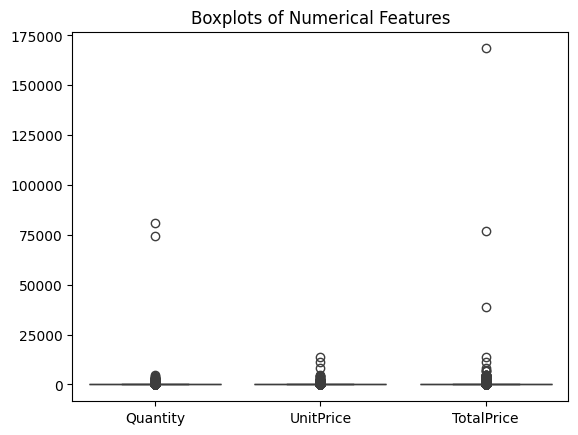

In [16]:
# checking for any outliers.
sns.boxplot(data=df[['Quantity', 'UnitPrice', 'TotalPrice']])

plt.title("Boxplots of Numerical Features")
plt.show()

### Outlier Observation in Quantity, UnitPrice, and TotalPrice

The dataset contains several extreme values in Quantity, UnitPrice, and TotalPrice.

These may represent:
- bulk purchases,
- wholesale transactions,
- premium products,
- or unusually large orders.

Since these transactions may contain valuable business information, the outliers were retained for analysis.

In [17]:
country_revenue = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

,TotalPrice
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


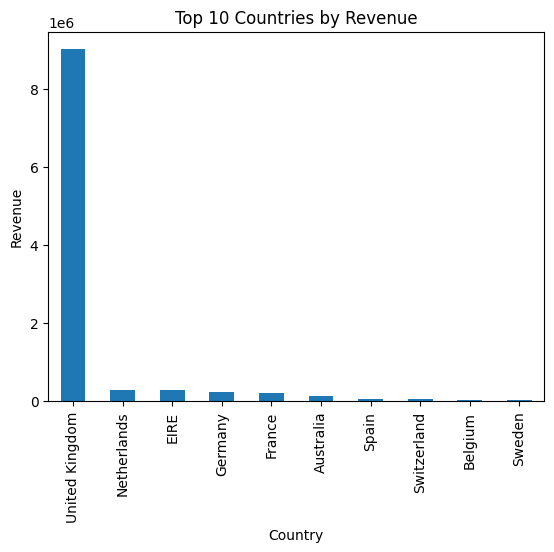

In [18]:
country_revenue.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

In [19]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


In [20]:
# Inspect unusually high quantity transaction
df[df['Description'] == 'PAPER CRAFT , LITTLE BIRDIE']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6


### Observation

The product "PAPER CRAFT , LITTLE BIRDIE" shows an unusually high purchase quantity of 80,995 units in a single transaction.

This may indicate:
- a bulk wholesale order,
- inventory movement,
- or an exceptional commercial purchase.

The transaction was retained because it represents valid business activity rather than a data error.

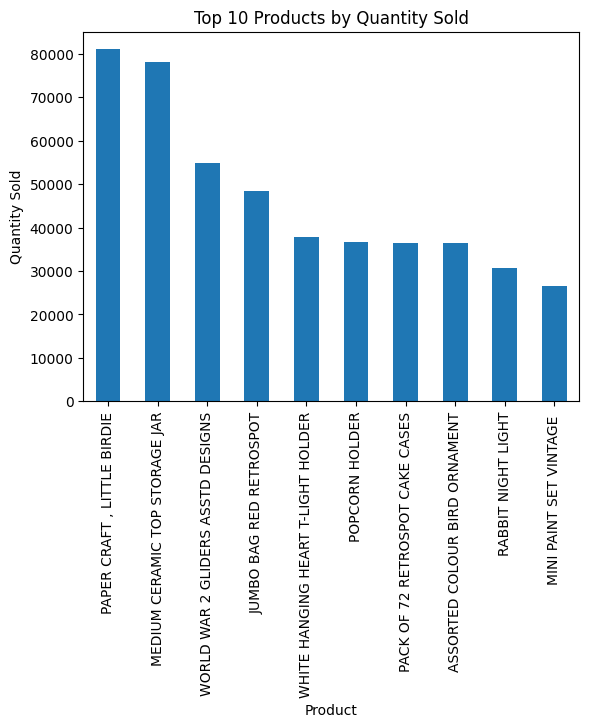

In [21]:
top_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()

In [22]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = (
    df.groupby('YearMonth')['TotalPrice']
    .sum()
)

monthly_revenue

,TotalPrice
YearMonth,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


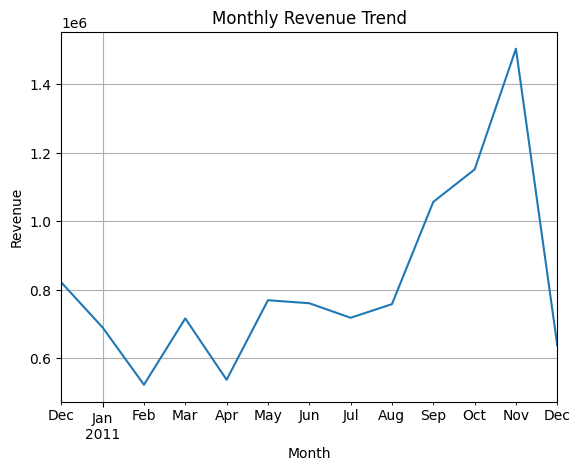

In [23]:
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

### Monthly Revenue Growth and Sharp Decline-

Revenue shows significant growth during September–November 2011, with November recording the highest sales.

The sharp decline in December 2011 is perhaps due to incomplete monthly data rather than an actual drop in business performance.

In [24]:
top_customers = (
    df.groupby('CustomerID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


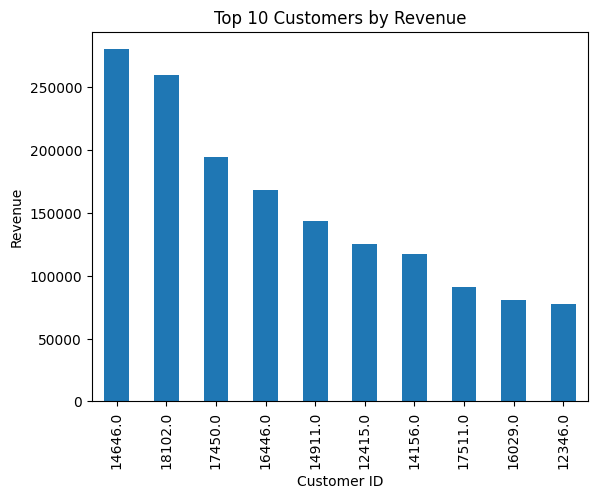

In [25]:
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

In [26]:
correlation_matrix = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

correlation_matrix

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
TotalPrice,0.907402,0.137381,1.000000


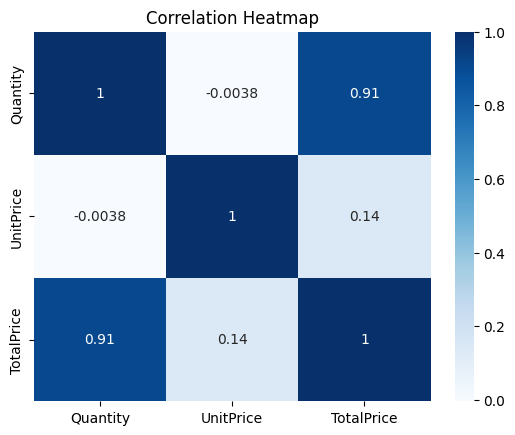

In [27]:
sns.heatmap(correlation_matrix, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

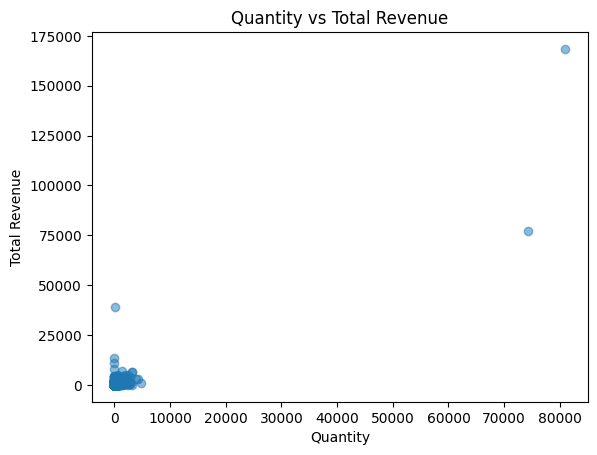

In [28]:
plt.scatter(
    df['Quantity'],
    df['TotalPrice'],
    alpha=0.5
)

plt.title("Quantity vs Total Revenue")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")

plt.show()

### Correlation Insights

- Quantity and TotalPrice show a strong positive correlation, indicating that larger purchase volumes significantly increase revenue.
- UnitPrice has a weak correlation with Quantity, suggesting that product pricing does not strongly influence purchase volume in this dataset.
- TotalPrice is more heavily driven by quantity purchased than by unit price alone.
- Most transactions are concentrated at lower quantity and revenue levels, while a few extreme bulk orders contribute disproportionately high revenue.

In [29]:
df['Hour'] = df['InvoiceDate'].dt.hour
hourly_sales = df.groupby('Hour')['InvoiceNo'].count()

hourly_sales

,InvoiceNo
Hour,
6,1
7,379
8,8797
9,33684
10,47597
11,55420
12,75986
13,69993
14,65057


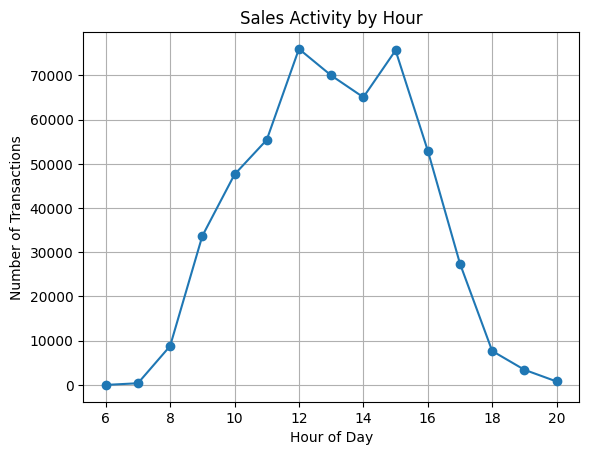

In [30]:
hourly_sales.plot(kind='line', marker='o')
plt.title("Sales Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.show()

### Customer Purchasing Behavior

Transaction activity peaks at 12 PM and 3 PM.

This suggests that customers are most active during standard business hours, with activity declining significantly during evening hours.

## 5. key findings

1. The United Kingdom generated the highest revenue by a significant margin, indicating a strong concentration of customers in that market.

2. Revenue showed strong growth during September–November 2011, with November recording the highest sales performance.

3. Several transactions contained unusually large purchase quantities, suggesting the presence of wholesale or bulk orders.

4. Quantity purchased showed a strong positive relationship with total revenue, making sales volume a key revenue driver.

5. Customer purchasing activity peaked during midday business hours, especially between 12 PM and 3 PM.

6. Some products demonstrated exceptionally high sales volumes, indicating strong product demand and popularity.

7. Negative quantities and unit prices were identified as cancelled transactions or pricing adjustments and were removed during data cleaning.